In [1]:
%load_ext autoreload
%autoreload

In [3]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pykep as pk
plt.rcParams.update({'font.size': 32})

In [4]:
path=r"~/rasmus/Decentralized-EO/licos/results/bmshj2018-factorized_qual=1_raw=split_seed=42_t=2024_05_12_18_33_48/"

In [5]:
rank_0 = pd.read_csv(os.path.join(path, "0.csv"))
rank_1 = pd.read_csv(os.path.join(path, "1.csv"))
rank_2 = pd.read_csv(os.path.join(path, "2.csv"))

In [ ]:
time_at_loss_rank_0 = pd.read_csv(os.path.join(path, "time_at_loss_rank1.csv"))

In [ ]:
loss_rank_0 = pd.read_csv(os.path.join(path, "loss_rank0.csv"))
loss_rank_1 = pd.read_csv(os.path.join(path, "loss_rank1.csv"))
loss_rank_2 = pd.read_csv(os.path.join(path, "loss_rank2.csv"))
time_at_loss_rank_0 = pd.read_csv(os.path.join(path, "time_at_loss_rank0.csv"))
time_at_loss_rank_1 = pd.read_csv(os.path.join(path, "time_at_loss_rank1.csv"))
time_at_loss_rank_2 = pd.read_csv(os.path.join(path, "time_at_loss_rank2.csv"))
time_at_loss_rank_0 = np.array(time_at_loss_rank_0[list(time_at_loss_rank_0.keys())[0]])
time_at_loss_rank_1 = np.array(time_at_loss_rank_1[list(time_at_loss_rank_1.keys())[0]])
time_at_loss_rank_2 = np.array(time_at_loss_rank_2[list(time_at_loss_rank_2.keys())[0]])
time_at_loss_rank_1 =[(time_at_loss_rank_1[n] - time_at_loss_rank_0[0])/(3600*24) for n in range(len(time_at_loss_rank_1))]
time_at_loss_rank_2 = [(time_at_loss_rank_2[n] - time_at_loss_rank_0[0])/(3600*24) for n in range(len(time_at_loss_rank_2))]
time_at_loss_rank_0 = [(time_at_loss_rank_0[n] - time_at_loss_rank_0[0])/(3600*24) for n in range(len(time_at_loss_rank_0))]

In [6]:
def activity_match(activity):
    if activity == "Training":
        return 2
    elif activity == "'Model_update":
        return 1
    else:
        return 0
    
def eclipse_status_match(eclipse_status):
    if eclipse_status:
        return 1
    else:
        return 0
    
def get_gs(known_actor):
    if known_actor == 'dict_keys([])':
        return []

    if known_actor == "dict_keys(['Maspalomas', 'Matera'])":
        return [0,1]

    if known_actor == "dict_keys(['Maspalomas'])":
        return [0]

    if known_actor == "dict_keys(['Matera', 'Svalbard'])":
        return [1,2]

    if known_actor == "dict_keys(['Matera'])":
        return [1]
    else:
        return [2]



In [7]:
eclipse_status_0 = [(lambda x : eclipse_status_match(x))(n) for n in rank_0["is_in_eclipse"] ]
eclipse_status_1 = [(lambda x : eclipse_status_match(x))(n) for n in rank_1["is_in_eclipse"] ]
eclipse_status_2 = [(lambda x : eclipse_status_match(x))(n) for n in rank_2["is_in_eclipse"] ]

In [8]:
time_rank_0=np.array(rank_0["timesteps"])
time_rank_1=np.array(rank_1["timesteps"])
time_rank_2=np.array(rank_2["timesteps"])
temp_rank_0=np.array(rank_0["temperature"])
temp_rank_1=np.array(rank_1["temperature"])
temp_rank_2=np.array(rank_2["temperature"])
time_rank_1 = [(time_rank_1[n] - time_rank_0[0])/(3600*24) for n in range(len(time_rank_1))]
time_rank_2 = [(time_rank_2[n] - time_rank_0[0])/(3600*24) for n in range(len(time_rank_2))]
time_rank_0 = [(time_rank_0[n] - time_rank_0[0])/(3600*24) for n in range(len(time_rank_0))]

In [9]:
activity_rank_0 =  [(lambda x: activity_match(x))(n)for n in rank_0["current_activity"]]
activity_rank_1 =  [(lambda x: activity_match(x))(n)for n in rank_1["current_activity"]]
activity_rank_2 =  [(lambda x: activity_match(x))(n)for n in rank_2["current_activity"]]
eclipse_status_rank_0 =  [(lambda x: eclipse_status_match(x))(n)for n in rank_0["is_in_eclipse"]]
eclipse_status_rank_1 =  [(lambda x: eclipse_status_match(x))(n)for n in rank_1["is_in_eclipse"]]
eclipse_status_rank_2 =  [(lambda x: eclipse_status_match(x))(n)for n in rank_2["is_in_eclipse"]]

In [11]:
param_rank_0 = [temp_rank_0, rank_0["state_of_charge"], eclipse_status_0]
param_rank_1 = [temp_rank_1, rank_1["state_of_charge"], eclipse_status_1]
param_rank_2 = [temp_rank_2, rank_2["state_of_charge"], eclipse_status_2]
labels = ["Temperature", "SoC", "Ecplise status"]                
#losses = [loss_rank_0, loss_rank_1, loss_rank_2]
#loss_times = [time_at_loss_rank_0, time_at_loss_rank_1, time_at_loss_rank_2]
times = [time_rank_0, time_rank_1, time_rank_2]     
times_in_hours = [np.array(times[i]) * pk.DAY2SEC / 3600 for i in range(3)]
params = [param_rank_0, param_rank_1, param_rank_2]              

# Convert to np array
for i in range(3):
    #losses[i] = np.array(losses[i])
    #loss_times[i] = np.array(loss_times[i])
    times[i] = np.array(times[i])
    times_in_hours[i] = np.array(times_in_hours[i])
    for j in range(3):
        params[i][j] = np.array(params[i][j])

In [14]:
import warnings
warnings.filterwarnings("ignore")

from tqdm import tqdm

t_days_max = max(times[0])
hours = np.arange(0, t_days_max*24, 1)

# Chunk all data within an hour into the same timestampe
df = pd.DataFrame(columns=["Time", "Temperature", "SoC", "Eclipse status", "Rank"])
for i in range(3):
    for hour in tqdm(hours):
        indices_of_entries = np.where((times_in_hours[i] >= hour) & (times_in_hours[i] < hour + 1))[0]
        data_dict = {"Time": hour / 24, "Temperature": params[i][0][indices_of_entries], "SoC": params[i][1][indices_of_entries], "Eclipse status": params[i][2][indices_of_entries], "Rank": i}
        df = pd.concat([df, pd.DataFrame(data_dict)], ignore_index=True)

df

100%|██████████| 721/721 [00:05<00:00, 140.66it/s]


,Time,Temperature,SoC,Eclipse status,Rank
0,0.000000,283.150395,0.499964,0,0
1,0.000000,283.155138,0.499531,0,0
2,0.000000,283.159881,0.499098,0,0
3,0.000000,283.164623,0.498665,0,0
4,0.000000,283.169364,0.498232,0,0
...,...,...,...,...,...
443209,29.958333,305.396137,0.999820,0,2
443210,29.958333,305.392213,0.999820,0,2
443211,29.958333,305.388290,0.999820,0,2
443212,29.958333,305.384368,0.999820,0,2


In [15]:
small_df_for_test = df.sample(1000)

IndexError: index 3 is out of bounds for axis 0 with size 3

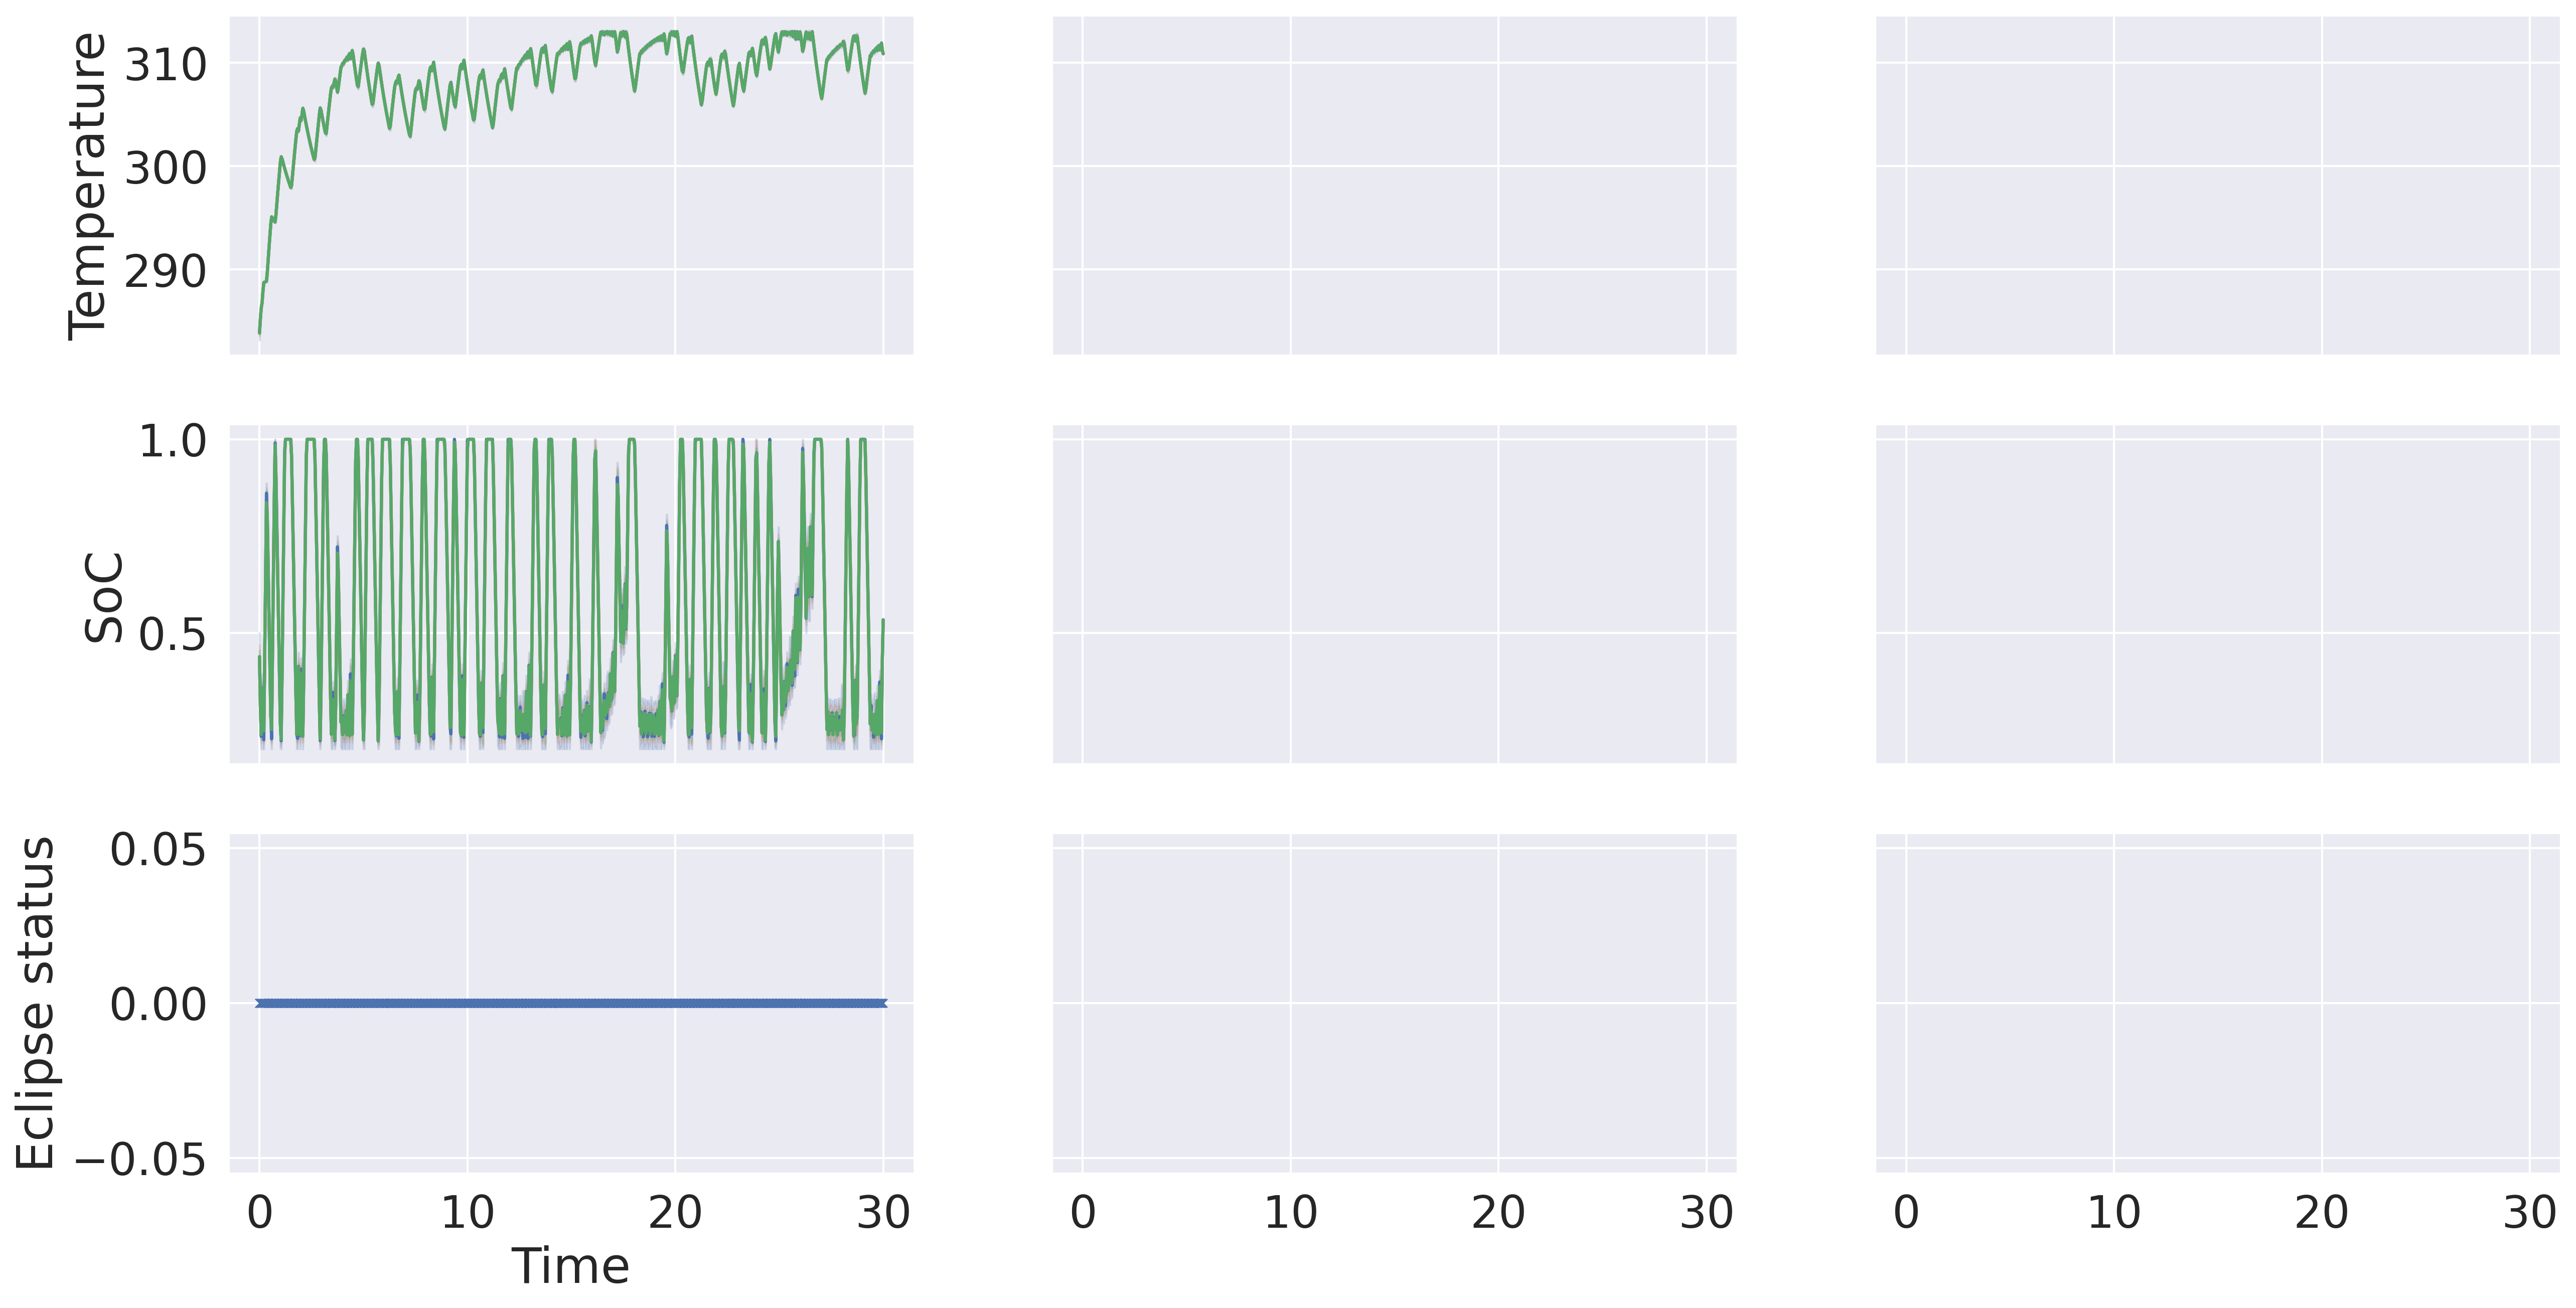

In [18]:
def plot_time_series(df,labels):
    # Create a plot showing the three satellites as columns and the different time series as rows. Use shared x-axis and y-axis to make the comparison easier.
    fig, axs = plt.subplots(3, 3, figsize=(20, 10), sharex=True,  sharey='row', dpi=300) 
    # Change fontsize to be smaller
    plt.rcParams.update({'font.size': 10})
    sns.set(font_scale=1.95)
    for i in range(3):
        for j in range(3):
            if labels[j] != "Eclipse status":
                sns.lineplot(x="Time", y=labels[j], data=df[df["Rank"] == i], ax=axs[j,i],errorbar=("pi",100),estimator="median")
                sns.lineplot(x="Time", y=labels[j], data=df[df["Rank"] == i], ax=axs[j,i],errorbar=("pi",50))
                sns.lineplot(x="Time", y=labels[j], data=df[df["Rank"] == i], ax=axs[j,i],errorbar=("pi",25))
            else:
                sns.scatterplot(x="Time", y=labels[j], data=df[df["Rank"] == i], ax=axs[j,i], s=15,marker="x")
        #sns.scatterplot(x=loss_times[i], y=losses[i].squeeze(), ax=axs[3,i], s=15,marker="x")
        axs[2,i].set_yscale('log')
        axs[2,i].set_yticks([1e-1, 1e0, 1e1])
    axs[0,0].set_title('Satellite 1')
    axs[0,1].set_title('Satellite 2')
    axs[0,2].set_title('Satellite 3')
    axs[0,0].set_ylabel('Temperature [K]')
    axs[0,0].set_yticks([280,290,300,310,320])
    # Draw vertical lines at 313.5K indicating max training temperature
    for i in range(3):
        axs[0,i].axhline(y=313.5, color='r', linestyle='--')
        # Annotate
        axs[0,i].annotate('  Max training temperature', xy=(0.5, 313.5), xytext=(0.5, 315), fontsize=12,
            arrowprops=dict(facecolor='black', shrink=0.05),
        )
    axs[1,0].set_ylabel('SoC')
    axs[1,0].set_yticks([0,0.5,1])
    # Draw vertical line at 0.2 indicating min SoC
    for i in range(3):
        axs[1,i].axhline(y=0.2, color='r', linestyle='--')
        # Annotate with arrow from below
        axs[1,i].annotate('  Min SoC', xy=(0.5, 0.2), xytext=(0.5, 0.1), fontsize=12,
            arrowprops=dict(facecolor='black', shrink=0.05),
        )
    axs[2,0].set_ylabel('Eclipse status')
    #axs[3,0].set_ylabel('Loss')
    axs[3,0].set_xlabel('Time [days]')
    axs[3,1].set_xlabel('Time [days]')
    axs[3,2].set_xlabel('Time [days]')
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.tight_layout()
    plt.savefig("telemetry.pdf")
    plt.show()

plot_time_series(df, df.keys()[1:])
# plot_time_series(small_df_for_test, losses, loss_times,df.keys()[1:])

In [ ]:
rank_1["state_of_charge"]

In [ ]:
loss_rank_2 = np.array(loss_rank_2[loss_rank_2.keys()])

In [ ]:
loss_2_delta = loss_rank_2[0] - loss_rank_2[-1]

In [ ]:
0.8 * loss_0_delta

In [ ]:
(loss_rank_2[0] - loss_rank_2[np.where(np.array(time_at_loss_rank_2) > 5)[0][0]]) / loss_2_delta

In [ ]:
np.argmin(np.array(time_at_loss_rank_0) > 5)

In [ ]:
loss_rank_1